In [5]:
# ============================================================
# HÜCRE 1: DRIVE BAĞLA + ZIP AÇ (Standart)
# ============================================================
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import zipfile, os
from pathlib import Path

print("🔍 Dosya aranıyor...")
search_results = !find /content/drive/MyDrive -name "MultiRes_ConfocFluo_HumanDentin.zip"

if search_results:
    ZIP_PATH = search_results[0]
    print(f"✅ Dosya bulundu: {ZIP_PATH}")
else:
    ZIP_PATH = "/content/drive/MyDrive/MultiRes_ConfocFluo_HumanDentin.zip"
    print("❌ Bulunamadı! ZIP_PATH'i manuel güncelle.")

EXTRACT_PATH = "/content/dataset"

# Zaten açık mı kontrol et
check = Path(EXTRACT_PATH) / "MultiRes_ConfocFluo_HumanDentin/ImagePatches128/Classified"
if check.exists():
    print("✅ Dataset zaten açık, tekrar açmaya gerek yok!")
else:
    if os.path.exists(ZIP_PATH):
        print("📦 Sadece ImagePatches128 açılıyor...")
        os.makedirs(EXTRACT_PATH, exist_ok=True)
        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            dosyalar = [f for f in z.namelist() if 'ImagePatches128' in f]
            toplam = len(dosyalar)
            print(f"Açılacak dosya sayısı: {toplam:,}")
            for i, d in enumerate(dosyalar):
                z.extract(d, EXTRACT_PATH)
                if i % 10000 == 0:
                    print(f"  {i:,}/{toplam:,} ({i/toplam*100:.0f}%)")
        print("✅ Açıldı!")
    else:
        print("⚠️ Zip bulunamadı!")

# Kontrol
p = check
for s in ["tubules","branches","both"]:
    sayi = len(list((p/s/"HR").glob("*.tif")))
    print(f"  {s}/HR: {sayi:,}")


Mounted at /content/drive
🔍 Dosya aranıyor...
✅ Dosya bulundu: /content/drive/MyDrive/MultiRes_ConfocFluo_HumanDentin.zip
📦 Sadece ImagePatches128 açılıyor...
Açılacak dosya sayısı: 361,873
  0/361,873 (0%)
  10,000/361,873 (3%)
  20,000/361,873 (6%)
  30,000/361,873 (8%)
  40,000/361,873 (11%)
  50,000/361,873 (14%)
  60,000/361,873 (17%)
  70,000/361,873 (19%)
  80,000/361,873 (22%)
  90,000/361,873 (25%)
  100,000/361,873 (28%)
  110,000/361,873 (30%)
  120,000/361,873 (33%)
  130,000/361,873 (36%)
  140,000/361,873 (39%)
  150,000/361,873 (41%)
  160,000/361,873 (44%)
  170,000/361,873 (47%)
  180,000/361,873 (50%)
  190,000/361,873 (53%)
  200,000/361,873 (55%)
  210,000/361,873 (58%)
  220,000/361,873 (61%)
  230,000/361,873 (64%)
  240,000/361,873 (66%)
  250,000/361,873 (69%)
  260,000/361,873 (72%)
  270,000/361,873 (75%)
  280,000/361,873 (77%)
  290,000/361,873 (80%)
  300,000/361,873 (83%)
  310,000/361,873 (86%)
  320,000/361,873 (88%)
  330,000/361,873 (91%)
  340,000/361

In [6]:
import torch, warnings
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from pathlib import Path
import tifffile
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE    = 32
NUM_EPOCHS    = 25
LR            = 1e-4
RANDOM_SEED   = 42
torch.manual_seed(RANDOM_SEED)

PATCHES_ROOT  = Path("/content/dataset/MultiRes_ConfocFluo_HumanDentin/ImagePatches128/Classified")
SINIFLAR      = ["tubules", "branches", "both"]
SINIF2IDX     = {s: i for i, s in enumerate(SINIFLAR)}
IDX2SINIF     = {i: s for s, i in SINIF2IDX.items()}
CLASS_WEIGHTS = torch.tensor([2.3807, 0.3868, 0.2325]).to(DEVICE)
TRAIN_ROIS    = ["roi01","roi02","roi03","roi04"]
VAL_ROIS      = ["roi05"]
TEST_ROIS     = ["roi06"]

def get_roi(filename):
    for p in Path(filename).stem.split('_'):
        if p.startswith('roi'):
            return p
    return None

def build_file_list(patches_root, siniflar, cozunurluk, roi_listesi):
    dosyalar = []
    for sinif in siniflar:
        klasor = patches_root / sinif / cozunurluk
        if not klasor.exists():
            continue
        for tif in sorted(klasor.glob("*.tif")):
            if get_roi(tif.name) in roi_listesi:
                dosyalar.append((str(tif), SINIF2IDX[sinif]))
    return dosyalar

class DentinDataset(Dataset):
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]
    def __init__(self, dosya_listesi, augmentation=False):
        self.dosya_listesi = dosya_listesi
        self.augmentation  = augmentation
        self.train_tf = transforms.Compose([
            transforms.RandomHorizontalFlip(0.5),
            transforms.RandomVerticalFlip(0.5),
            transforms.RandomRotation(30),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            transforms.Normalize(self.MEAN, self.STD)
        ])
        self.val_tf = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(self.MEAN, self.STD)
        ])
    def __len__(self): return len(self.dosya_listesi)
    def __getitem__(self, idx):
        yol, etiket = self.dosya_listesi[idx]
        img = Image.fromarray(tifffile.imread(yol)).convert("RGB")
        tf  = self.train_tf if self.augmentation else self.val_tf
        return tf(img), torch.tensor(etiket, dtype=torch.long)

train_d = DentinDataset(build_file_list(PATCHES_ROOT, SINIFLAR, "HR", TRAIN_ROIS), True)
val_d   = DentinDataset(build_file_list(PATCHES_ROOT, SINIFLAR, "HR", VAL_ROIS),   False)
test_d  = DentinDataset(build_file_list(PATCHES_ROOT, SINIFLAR, "HR", TEST_ROIS),  False)

train_loader = DataLoader(train_d, BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_d,   BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_d,  BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ Device : {DEVICE} ({torch.cuda.get_device_name(0)})")
print(f"✅ Train  : {len(train_d):,} | Val: {len(val_d):,} | Test: {len(test_d):,}")

✅ Device : cuda (Tesla T4)
✅ Train  : 60,125 | Val: 13,393 | Test: 16,946


In [7]:
def resnet50_olustur(num_classes=3):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_features, 256),
        nn.ReLU(True),
        nn.Dropout(0.2),
        nn.Linear(256, num_classes)
    )
    return model

model = resnet50_olustur().to(DEVICE)
toplam = sum(p.numel() for p in model.parameters())
print(f"✅ ResNet50 yüklendi (ImageNet pretrained)")
print(f"   Toplam parametre: {toplam:,}")
test_in = torch.randn(2, 3, 128, 128).to(DEVICE)
print(f"   Giriş → Çıkış: {test_in.shape} → {model(test_in).shape} ✓")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 173MB/s]


✅ ResNet50 yüklendi (ImageNet pretrained)
   Toplam parametre: 24,033,347
   Giriş → Çıkış: torch.Size([2, 3, 128, 128]) → torch.Size([2, 3]) ✓


In [8]:
criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
tarih = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
en_iyi_val_acc = 0.0
en_iyi_epoch   = 0

# ── AŞAMA 1: Sadece FC (5 epoch) ───────────────────────────
print("="*60)
print("AŞAMA 1: FC katmanı (5 epoch, backbone donduruldu)")
print("="*60)

for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

optimizer1 = optim.Adam(model.fc.parameters(), lr=1e-3, weight_decay=1e-4)

for epoch in range(1, 6):
    model.train()
    t_loss, t_d, t_t = 0, 0, 0
    for imgs, eti in train_loader:
        imgs, eti = imgs.to(DEVICE), eti.to(DEVICE)
        optimizer1.zero_grad()
        out = model(imgs); loss = criterion(out, eti)
        loss.backward(); optimizer1.step()
        t_loss += loss.item()*imgs.size(0)
        t_d += (out.argmax(1)==eti).sum().item()
        t_t += imgs.size(0)
    model.eval()
    v_loss, v_d, v_t = 0, 0, 0
    with torch.no_grad():
        for imgs, eti in val_loader:
            imgs, eti = imgs.to(DEVICE), eti.to(DEVICE)
            out = model(imgs); loss = criterion(out, eti)
            v_loss += loss.item()*imgs.size(0)
            v_d += (out.argmax(1)==eti).sum().item()
            v_t += imgs.size(0)
    tl,vl = t_loss/t_t, v_loss/v_t
    ta,va = t_d/t_t*100, v_d/v_t*100
    tarih["train_loss"].append(tl); tarih["val_loss"].append(vl)
    tarih["train_acc"].append(ta);  tarih["val_acc"].append(va)
    if va > en_iyi_val_acc:
        en_iyi_val_acc = va; en_iyi_epoch = epoch
        torch.save(model.state_dict(), "resnet50_best.pth")
        print(f"Epoch {epoch}/5  | Train: {tl:.4f} %{ta:.1f} | Val: {vl:.4f} %{va:.1f} ★")
    else:
        print(f"Epoch {epoch}/5  | Train: {tl:.4f} %{ta:.1f} | Val: {vl:.4f} %{va:.1f}")

# ── AŞAMA 2: Full fine-tune (20 epoch) ─────────────────────
print(f"\n{'='*60}")
print("AŞAMA 2: Full fine-tune (20 epoch)")
print("="*60)

for param in model.parameters():
    param.requires_grad = True

optimizer2 = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer2, T_max=20)

for epoch in range(6, 26):
    model.train()
    t_loss, t_d, t_t = 0, 0, 0
    for imgs, eti in train_loader:
        imgs, eti = imgs.to(DEVICE), eti.to(DEVICE)
        optimizer2.zero_grad()
        out = model(imgs); loss = criterion(out, eti)
        loss.backward(); optimizer2.step()
        t_loss += loss.item()*imgs.size(0)
        t_d += (out.argmax(1)==eti).sum().item()
        t_t += imgs.size(0)
    model.eval()
    v_loss, v_d, v_t = 0, 0, 0
    with torch.no_grad():
        for imgs, eti in val_loader:
            imgs, eti = imgs.to(DEVICE), eti.to(DEVICE)
            out = model(imgs); loss = criterion(out, eti)
            v_loss += loss.item()*imgs.size(0)
            v_d += (out.argmax(1)==eti).sum().item()
            v_t += imgs.size(0)
    tl,vl = t_loss/t_t, v_loss/v_t
    ta,va = t_d/t_t*100, v_d/v_t*100
    tarih["train_loss"].append(tl); tarih["val_loss"].append(vl)
    tarih["train_acc"].append(ta);  tarih["val_acc"].append(va)
    scheduler.step()
    if va > en_iyi_val_acc:
        en_iyi_val_acc = va; en_iyi_epoch = epoch
        torch.save(model.state_dict(), "resnet50_best.pth")
        print(f"Epoch {epoch:2d}/25 | Train: {tl:.4f} %{ta:.1f} | Val: {vl:.4f} %{va:.1f} ★")
    else:
        print(f"Epoch {epoch:2d}/25 | Train: {tl:.4f} %{ta:.1f} | Val: {vl:.4f} %{va:.1f}")

print(f"\n✅ Bitti! En iyi: %{en_iyi_val_acc:.2f} (epoch {en_iyi_epoch})")

AŞAMA 1: FC katmanı (5 epoch, backbone donduruldu)
Epoch 1/5  | Train: 0.8105 %61.2 | Val: 0.7278 %67.6 ★
Epoch 2/5  | Train: 0.7834 %62.6 | Val: 0.7149 %67.9 ★
Epoch 3/5  | Train: 0.7726 %63.1 | Val: 0.6628 %70.0 ★
Epoch 4/5  | Train: 0.7675 %63.2 | Val: 0.6356 %73.2 ★
Epoch 5/5  | Train: 0.7671 %62.6 | Val: 0.7458 %63.2

AŞAMA 2: Full fine-tune (20 epoch)
Epoch  6/25 | Train: 0.6576 %67.4 | Val: 0.5363 %76.9 ★
Epoch  7/25 | Train: 0.5995 %71.3 | Val: 0.5338 %77.5 ★
Epoch  8/25 | Train: 0.5851 %71.9 | Val: 0.6364 %72.1
Epoch  9/25 | Train: 0.5705 %73.0 | Val: 0.5970 %73.0
Epoch 10/25 | Train: 0.5649 %72.9 | Val: 0.5905 %76.1
Epoch 11/25 | Train: 0.5529 %73.6 | Val: 0.5774 %73.9
Epoch 12/25 | Train: 0.5405 %73.9 | Val: 0.5883 %74.4
Epoch 13/25 | Train: 0.5307 %74.6 | Val: 0.5236 %76.8
Epoch 14/25 | Train: 0.5218 %74.6 | Val: 0.5919 %74.7
Epoch 15/25 | Train: 0.5100 %75.5 | Val: 0.5657 %74.5
Epoch 16/25 | Train: 0.4978 %75.5 | Val: 0.5655 %76.6
Epoch 17/25 | Train: 0.4935 %76.0 | Val: 0

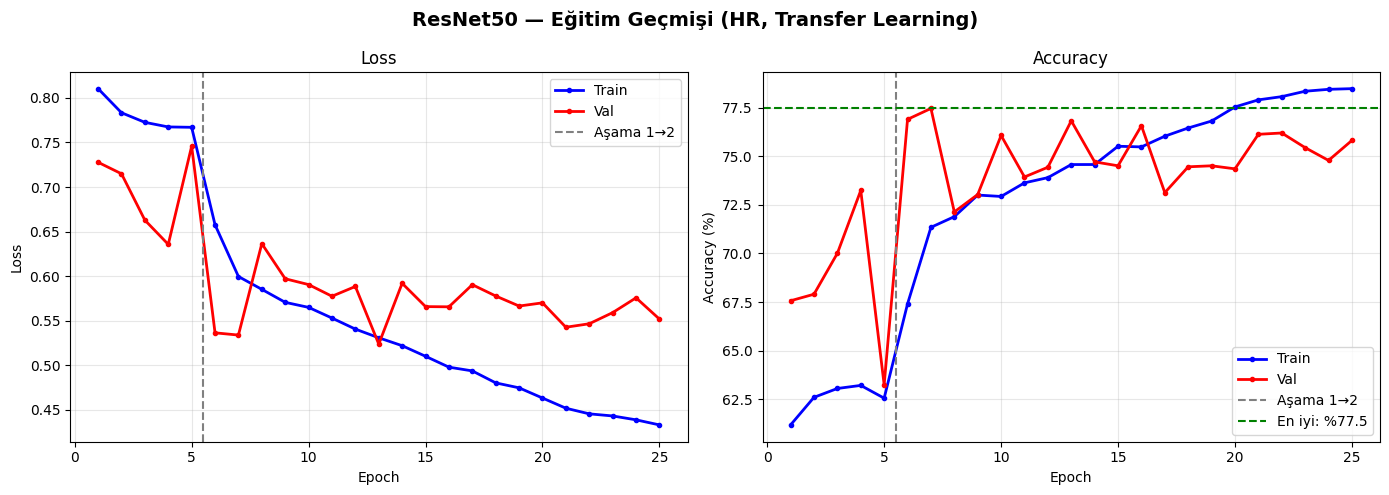

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ResNet50 — Eğitim Geçmişi (HR, Transfer Learning)",
             fontsize=14, fontweight='bold')
ep = range(1, len(tarih["train_loss"]) + 1)
axes[0].plot(ep, tarih["train_loss"], 'b-o', ms=3, lw=2, label="Train")
axes[0].plot(ep, tarih["val_loss"],   'r-o', ms=3, lw=2, label="Val")
axes[0].axvline(x=5.5, color='gray', ls='--', lw=1.5, label="Aşama 1→2")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(ep, tarih["train_acc"], 'b-o', ms=3, lw=2, label="Train")
axes[1].plot(ep, tarih["val_acc"],   'r-o', ms=3, lw=2, label="Val")
axes[1].axvline(x=5.5, color='gray', ls='--', lw=1.5, label="Aşama 1→2")
axes[1].axhline(y=en_iyi_val_acc, color='g', ls='--', lw=1.5,
                label=f"En iyi: %{en_iyi_val_acc:.1f}")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("resnet50_egitim.png", dpi=150, bbox_inches='tight')
plt.show()

RESNET50 — TEST SONUÇLARI (HR)
              precision    recall  f1-score   support

     tubules     0.2459    0.8205    0.3784      1281
    branches     0.8158    0.5857    0.6819      3493
        both     0.8704    0.7268    0.7922     12172

    accuracy                         0.7048     16946
   macro avg     0.6440    0.7110    0.6175     16946
weighted avg     0.8120    0.7048    0.7382     16946

Per-class Sensitivity & Specificity:
Sınıf         Sensitivity  Specificity
--------------------------------------
tubules            0.8205       0.7943
branches           0.5857       0.9657
both               0.7268       0.7241

ROC-AUC (macro): 0.8789


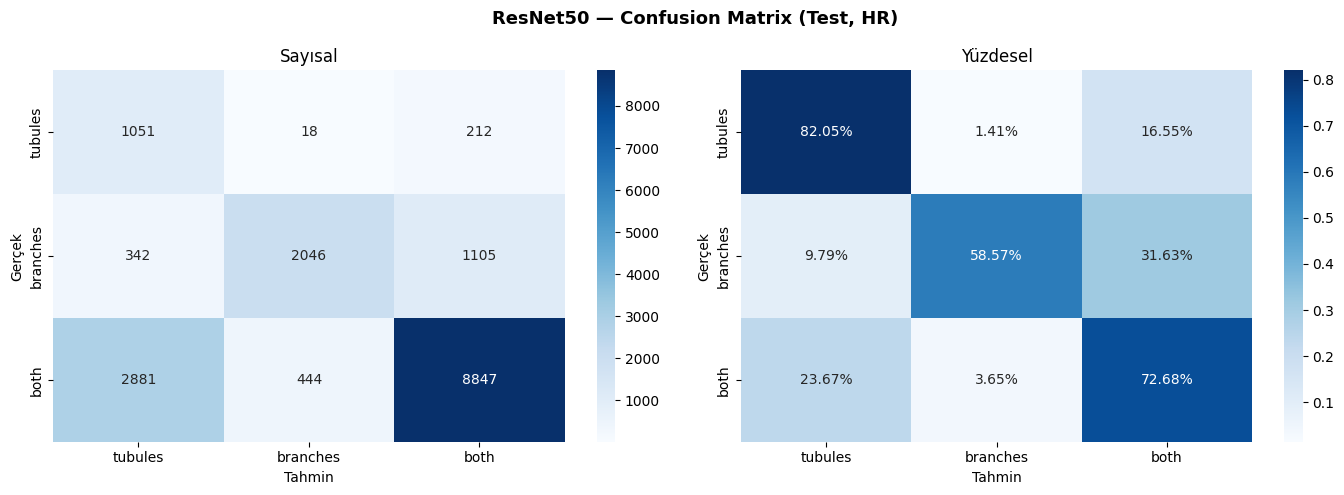

✅ Tamamlandı!


In [10]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns

model.load_state_dict(torch.load("resnet50_best.pth"))
model.eval()

tum_tahmin, tum_gercek, tum_prob = [], [], []
with torch.no_grad():
    for imgs, eti in test_loader:
        imgs = imgs.to(DEVICE)
        out  = model(imgs)
        prob = torch.softmax(out, dim=1).cpu().numpy()
        tum_prob.extend(prob)
        tum_tahmin.extend(out.argmax(1).cpu().numpy())
        tum_gercek.extend(eti.numpy())

tum_tahmin = np.array(tum_tahmin)
tum_gercek = np.array(tum_gercek)
tum_prob   = np.array(tum_prob)

print("="*60)
print("RESNET50 — TEST SONUÇLARI (HR)")
print("="*60)
print(classification_report(tum_gercek, tum_tahmin,
                            target_names=SINIFLAR, digits=4))

print("Per-class Sensitivity & Specificity:")
print(f"{'Sınıf':<12} {'Sensitivity':>12} {'Specificity':>12}")
print("-"*38)
for i, sinif in enumerate(SINIFLAR):
    tp = ((tum_tahmin==i)&(tum_gercek==i)).sum()
    fn = ((tum_tahmin!=i)&(tum_gercek==i)).sum()
    tn = ((tum_tahmin!=i)&(tum_gercek!=i)).sum()
    fp = ((tum_tahmin==i)&(tum_gercek!=i)).sum()
    sens = tp/(tp+fn) if (tp+fn)>0 else 0
    spec = tn/(tn+fp) if (tn+fp)>0 else 0
    print(f"{sinif:<12} {sens:>12.4f} {spec:>12.4f}")

auc = roc_auc_score(tum_gercek, tum_prob, multi_class='ovr', average='macro')
print(f"\nROC-AUC (macro): {auc:.4f}")

cm      = confusion_matrix(tum_gercek, tum_tahmin)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ResNet50 — Confusion Matrix (Test, HR)", fontsize=13, fontweight='bold')
sns.heatmap(cm,      annot=True, fmt='d',    cmap='Blues', ax=axes[0],
            xticklabels=SINIFLAR, yticklabels=SINIFLAR)
axes[0].set_xlabel("Tahmin"); axes[0].set_ylabel("Gerçek"); axes[0].set_title("Sayısal")
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=SINIFLAR, yticklabels=SINIFLAR)
axes[1].set_xlabel("Tahmin"); axes[1].set_ylabel("Gerçek"); axes[1].set_title("Yüzdesel")
plt.tight_layout()
plt.savefig("resnet50_confusion.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Tamamlandı!")